In [1]:
# **Autoencoder für Anomalieerkennung
import os
import pandas as pd
import pymongo
import numpy as np
import base64
from io import BytesIO
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns

2025-01-09 16:16:58.962554: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-09 16:16:59.786499: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def load_data():
    # Verbindung zur Datenbank herstellen
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()

    # Daten aus der 'canvassamples'-Collection laden
    canvassamples_collection = db['canvassamples']
    canvassamples_cursor = canvassamples_collection.find()
    canvassamples_data = list(canvassamples_cursor)
    canvassamples_df = pd.DataFrame(canvassamples_data)

    # Daten aus der 'fingerprints'-Collection laden
    fingerprints_collection = db['fingerprints']
    fingerprints_cursor = fingerprints_collection.find()
    fingerprints_data = list(fingerprints_cursor)
    fingerprints_df = pd.DataFrame(fingerprints_data)

    return canvassamples_df, fingerprints_df

# Daten laden
canvassamples_df, fingerprints_df = load_data()

In [3]:
# Daten zusammenführen
merged_df = pd.merge(canvassamples_df, fingerprints_df, left_on='fingerprintId', right_on='_id', suffixes=('_sample', '_fingerprint'))

# Benutzer-IDs extrahieren
user_ids = merged_df['username'].unique()

# DataFrames für jeden Benutzer erstellen
user_dfs = {user_id: merged_df[merged_df['username'] == user_id] for user_id in user_ids}

In [4]:
def process_sample(base64_str, target_size):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(BytesIO(image_data)).convert('RGB')
        image = image.resize(target_size)
        return np.array(image) / 255.0
    except Exception as e:
        print(f"Fehler beim Dekodieren des Bildes: {e}")
        return None

In [5]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence

def split_data_indices(df):
    if len(df) < 3:
        raise ValueError("Nicht genügend Samples zum Aufteilen.")
    indices = df.index.values
    X_train_indices, X_temp_indices = train_test_split(indices, test_size=0.3, random_state=42)
    X_val_indices, X_test_indices = train_test_split(X_temp_indices, test_size=0.3333, random_state=42)
    return X_train_indices, X_val_indices, X_test_indices

class DataGenerator(Sequence):
    def __init__(self, df, indices, target_size, batch_size=32):
        self.df = df
        self.indices = indices
        self.target_size = target_size
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil(len(self.indices) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_samples = [process_sample(self.df.at[i, 'sampleData'], self.target_size) for i in batch_indices]
        batch_samples = [sample for sample in batch_samples if sample is not None]
        batch_samples = np.array(batch_samples)
        return batch_samples, batch_samples  # Input und Output sind gleich für Autoencoder

In [6]:
target_size = (64, 64)  # Zielgröße der Bilder

user_generators = {}
for user_id, df in user_dfs.items():
    try:
        X_train_indices, X_val_indices, X_test_indices = split_data_indices(df)
        train_generator = DataGenerator(df, X_train_indices, target_size, batch_size=32)
        val_generator = DataGenerator(df, X_val_indices, target_size, batch_size=32)
        test_generator = DataGenerator(df, X_test_indices, target_size, batch_size=32)
        user_generators[user_id] = (train_generator, val_generator, test_generator)
    except Exception as e:
        print(f"Fehler bei der Datenaufteilung für Benutzer {user_id}: {e}")

In [7]:
def create_cnn_autoencoder(input_shape):
    input_layer = Input(shape=input_shape)
    
    # Encoder
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)
    
    # Decoder
    x = Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(input_shape[2], (3, 3), activation='sigmoid', padding='same')(x)
    
    autoencoder = Model(inputs=input_layer, outputs=decoded)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return autoencoder

In [8]:
# Beispielhafter Benutzer
example_user_id = next(iter(user_generators))
train_generator, val_generator, test_generator = user_generators[example_user_id]

# Eingabeform
for batch in train_generator:
    input_shape = batch[0].shape[1:]
    break

# Modell erstellen
autoencoder = create_cnn_autoencoder(input_shape)

# Modell trainieren
autoencoder.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator
)

2025-01-09 16:20:33.624768: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-09 16:20:33.788264: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-09 16:20:33.788578: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Epoch 1/50


2025-01-09 16:20:34.991431: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8906
2025-01-09 16:20:35.989196: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x5d6e0a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-01-09 16:20:35.989242: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
2025-01-09 16:20:36.010448: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-01-09 16:20:36.195103: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2188/2188 [==============================] - 30s 13ms/step - loss: 0.0068 - val_loss: 0.0025
Epoch 2/50
2188/2188 [==============================] - 27s 13ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 3/50
2188/2188 [==============================] - 27s 12ms/step - loss: 0.0020 - val_loss: 0.0018
Epoch 4/50
2188/2188 [==============================] - 27s 12ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 5/50
2188/2188 [==============================] - 28s 13ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 6/50
2188/2188 [==============================] - 28s 13ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 7/50
2188/2188 [==============================] - 27s 12ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 8/50
2188/2188 [==============================] - 27s 12ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 9/50
2188/2188 [==============================] - 27s 12ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 10/50
2188/2188 [==============================] - 28s 13ms/step - lo

In [9]:
# Verzeichnis für Modelle erstellen
model_dir = "Modelle/Autoencoder_CNN"
os.makedirs(model_dir, exist_ok=True)

# Beispielhafter Benutzer
example_user_id = next(iter(user_generators))
train_generator, val_generator, test_generator = user_generators[example_user_id]

# Eingabeform
for batch in train_generator:
    input_shape = batch[0].shape[1:]
    break

# Modell erstellen
autoencoder = create_cnn_autoencoder(input_shape)

# Modell trainieren
autoencoder.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator
)

# Modell speichern
model_path = os.path.join(model_dir, "autoencoder_model.h5")
autoencoder.save(model_path)
print(f"Modell gespeichert unter: {model_path}")

Epoch 1/50
2188/2188 [==============================] - 28s 13ms/step - loss: 0.0048 - val_loss: 0.0023
Epoch 2/50
2188/2188 [==============================] - 27s 13ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 3/50
2188/2188 [==============================] - 28s 13ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 4/50
2188/2188 [==============================] - 28s 13ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 5/50
2188/2188 [==============================] - 28s 13ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 6/50
1133/2188 [==============>...............] - ETA: 10s - loss: 0.0012

KeyboardInterrupt: 

In [10]:
def calculate_reconstruction_errors(model, generator):
    errors = []
    for batch in generator:
        X, _ = batch
        reconstructed = model.predict(X)
        batch_errors = np.mean(np.square(X - reconstructed), axis=(1,2,3))
        errors.extend(batch_errors)
    return np.array(errors)

# Fehler für alle Benutzer berechnen
user_errors = {}
for user_id in user_ids:
    _, _, test_generator = user_generators[user_id]
    errors = calculate_reconstruction_errors(autoencoder, test_generator)
    user_errors[user_id] = errors

1/1 [==============================] - 0s 12ms/step


KeyboardInterrupt: 

In [11]:
# Schwellenwert basierend auf dem Beispielbenutzer
threshold = np.mean(user_errors[example_user_id]) + 2 * np.std(user_errors[example_user_id])
print(f"Schwellenwert: {threshold}")

# Klassifikation und Evaluierung
true_labels = []
predicted_labels = []

for user_id in user_ids:
    errors = user_errors[user_id]
    predictions = ['Benutzer' if e <= threshold else 'Anomalie' for e in errors]
    predicted_labels.extend(predictions)
    labels = ['Benutzer' if user_id == example_user_id else 'Anomalie'] * len(errors)
    true_labels.extend(labels)

In [12]:
from sklearn.metrics import confusion_matrix, classification_report

# Konfusionsmatrix und Bericht
conf_matrix = confusion_matrix(true_labels, predicted_labels, labels=['Benutzer', 'Anomalie'])
report = classification_report(true_labels, predicted_labels, target_names=['Benutzer', 'Anomalie'])

print('Konfusionsmatrix:')
print(conf_matrix)
print('\nKlassifikationsbericht:')
print(report)

In [13]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benutzer', 'Anomalie'],
            yticklabels=['Benutzer', 'Anomalie'])
plt.xlabel('Vorhergesagte Labels')
plt.ylabel('Wahre Labels')
plt.title('Konfusionsmatrix')
plt.show()

In [14]:
# Rekonstruktionsfehler des Beispielbenutzers
reconstruction_errors = user_errors[example_user_id]

plt.figure(figsize=(10, 6))
sns.histplot(reconstruction_errors, bins=50, kde=True)
plt.axvline(threshold, color='red', linestyle='--', label='Schwellenwert')
plt.xlabel('Rekonstruktionsfehler')
plt.ylabel('Anzahl')
plt.title('Verteilung der Rekonstruktionsfehler')
plt.legend()
plt.show()

NameError: name 'user_errors' is not defined

: 

: 

In [15]:
print("Form von original:", original.shape)
input_data = np.expand_dims(original, axis=0)  # Ergebnis: (1, 64, 64, 3)
# Anomalien identifizieren
anomalies = reconstruction_errors > threshold
anomaly_indices = np.where(anomalies)[0]

# Einige Anomalien anzeigen
n = min(5, len(anomaly_indices))
for idx in anomaly_indices[:n]:
    # Batch aus dem Generator abrufen
    X_batch, _ = test_generator[idx]
    
    # Form des Batches überprüfen
    print("Form von X_batch:", X_batch.shape)  # Sollte (Batchgröße, 64, 64, 3) sein
    
    # Ein einzelnes Bild aus dem Batch auswählen
    original = X_batch[0]  # Erstes Bild im Batch
    
    # Form von 'original' überprüfen
    print("Form von original:", original.shape)  # Sollte (64, 64, 3) sein
    
    # Eingabedaten vorbereiten
    input_data = np.expand_dims(original, axis=0)  # Ergebnis: (1, 64, 64, 3)
    
    # Vorhersage
    reconstructed = autoencoder.predict(input_data)
    reconstructed_image = reconstructed[0]
    
    plt.figure(figsize=(6, 3))

    # Originalbild
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title('Original')
    plt.axis('off')

    # Rekonstruiertes Bild
    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed_image)
    plt.title('Rekonstruiert')
    plt.axis('off')

    plt.show()

# Testing Models

1/1 [==============================] - 0s 12ms/step
Berechneter Schwellenwert: 0.0015811080814557414

Konfusionsmatrix:
[[  97    3]
 [1819   81]]

Klassifikationsbericht:
                  precision    recall  f1-score   support

      Benutzer 1       0.05      0.97      0.10       100
Nicht Benutzer 1       0.96      0.04      0.08      1900

        accuracy                           0.09      2000
       macro avg       0.51      0.51      0.09      2000
    weighted avg       0.92      0.09      0.08      2000



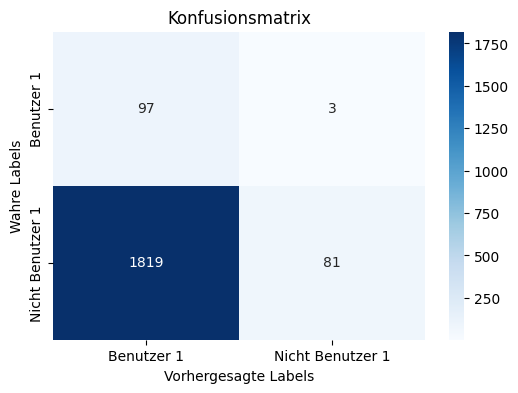


Klassifikationsergebnisse pro Benutzer:
           Benutzer  Richtig Positive  Falsch Positive  Richtig Negative  \
0    benutzername_1                97                0                 0   
1    benutzername_3                 0               98                 2   
2    benutzername_4                 0               90                10   
3    benutzername_5                 0               96                 4   
4    benutzername_6                 0               91                 9   
5    benutzername_7                 0               98                 2   
6    benutzername_8                 0               85                15   
7    benutzername_9                 0               98                 2   
8   benutzername_10                 0               93                 7   
9   benutzername_11                 0               97                 3   
10  benutzername_13                 0               97                 3   
11  benutzername_14                 0          

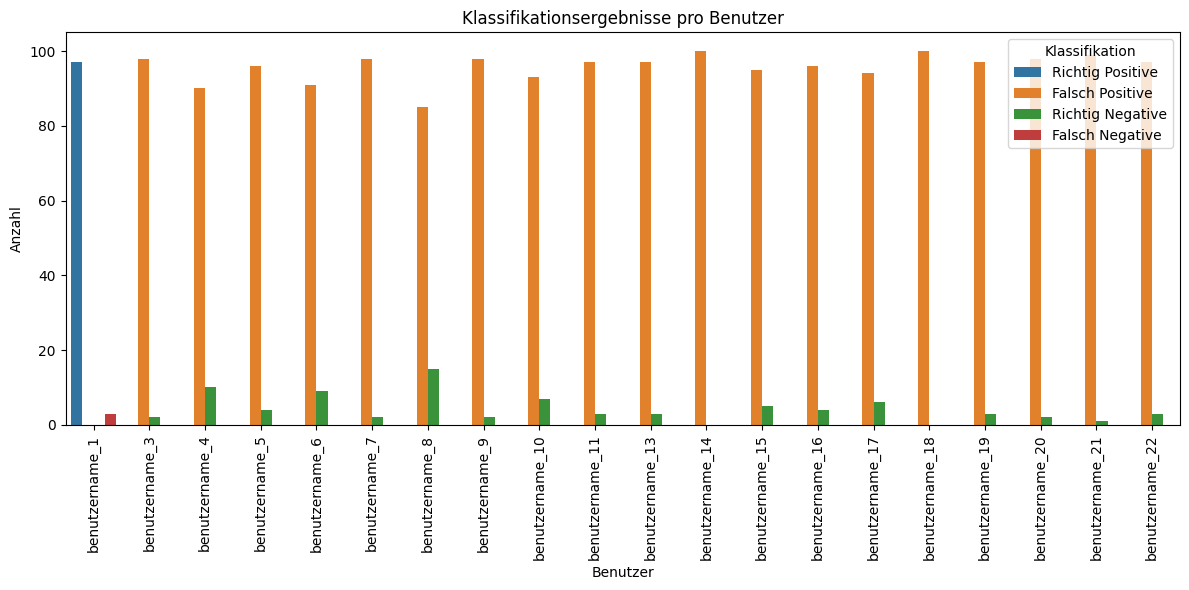

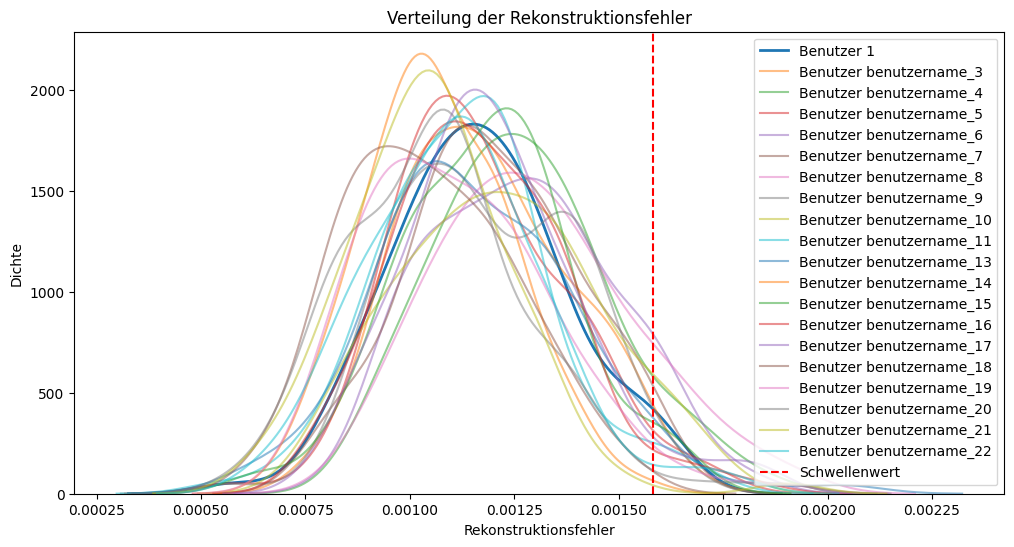


Modellleistung:
Das Modell hat Schwierigkeiten bei der Unterscheidung der Benutzer.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Beispielbenutzer definieren
example_user_id = 'benutzername_1'

# Rekonstruktionsfehler für begrenzte Testdaten berechnen
def calculate_reconstruction_error_limited(model, generator, limit=100):
    reconstruction_errors = []
    count = 0
    for batch in generator:
        if count >= limit:
            break
        X, _ = batch
        X = np.reshape(X, (-1, 64, 64, 3))  # Reshape für CNN
        reconstructed = model.predict(X)
        errors = np.mean(np.square(X - reconstructed), axis=(1,2,3))
        reconstruction_errors.extend(errors)
        count += len(X)
    return np.array(reconstruction_errors[:limit])

# Rekonstruktionsfehler für alle Benutzer berechnen
user_errors = {}
for user_id in user_ids:
    _, _, test_generator = user_generators[user_id]
    user_errors[user_id] = calculate_reconstruction_error_limited(autoencoder, test_generator)

# Schwellenwert basierend auf Beispielbenutzer berechnen
threshold = np.mean(user_errors[example_user_id]) + 2 * np.std(user_errors[example_user_id])
print(f"Berechneter Schwellenwert: {threshold}")

# Klassifikation der Fehler
def classify_errors(errors, threshold):
    return ["Benutzer 1" if error <= threshold else "Nicht Benutzer 1" for error in errors]

# Klassifikationsergebnisse für jeden Benutzer
classification_results = {}
for user_id, errors in user_errors.items():
    classification_results[user_id] = classify_errors(errors, threshold)

# Labels vorbereiten
true_labels = []
predicted_labels = []
for user_id in user_ids:
    labels = ["Benutzer 1" if user_id == example_user_id else "Nicht Benutzer 1"] * len(user_errors[user_id])
    true_labels.extend(labels)
    predicted_labels.extend(classification_results[user_id])

# Konfusionsmatrix und Bericht erstellen
conf_matrix = confusion_matrix(true_labels, predicted_labels, labels=["Benutzer 1", "Nicht Benutzer 1"])
class_report = classification_report(true_labels, predicted_labels, target_names=["Benutzer 1", "Nicht Benutzer 1"])

# Ergebnisse ausgeben
print("\nKonfusionsmatrix:")
print(conf_matrix)
print("\nKlassifikationsbericht:")
print(class_report)

# Konfusionsmatrix visualisieren
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Benutzer 1", "Nicht Benutzer 1"],
            yticklabels=["Benutzer 1", "Nicht Benutzer 1"])
plt.xlabel('Vorhergesagte Labels')
plt.ylabel('Wahre Labels')
plt.title('Konfusionsmatrix')
plt.show()

# Ergebnistabelle erstellen
results = []
for user_id in user_ids:
    user_true = ["Benutzer 1" if user_id == example_user_id else "Nicht Benutzer 1"] * len(user_errors[user_id])
    user_pred = classification_results[user_id]
    
    tp = sum((np.array(user_true) == "Benutzer 1") & (np.array(user_pred) == "Benutzer 1"))
    fp = sum((np.array(user_true) == "Nicht Benutzer 1") & (np.array(user_pred) == "Benutzer 1"))
    tn = sum((np.array(user_true) == "Nicht Benutzer 1") & (np.array(user_pred) == "Nicht Benutzer 1"))
    fn = sum((np.array(user_true) == "Benutzer 1") & (np.array(user_pred) == "Nicht Benutzer 1"))
    
    results.append({
        "Benutzer": user_id,
        "Richtig Positive": tp,
        "Falsch Positive": fp,
        "Richtig Negative": tn,
        "Falsch Negative": fn
    })

results_table = pd.DataFrame(results)
print("\nKlassifikationsergebnisse pro Benutzer:")
print(results_table)

# Ergebnisse visualisieren
plt.figure(figsize=(12, 6))
results_melted = results_table.melt(id_vars='Benutzer', 
                                  value_vars=['Richtig Positive', 'Falsch Positive', 
                                            'Richtig Negative', 'Falsch Negative'],
                                  var_name='Klassifikation', value_name='Anzahl')

sns.barplot(data=results_melted, x='Benutzer', y='Anzahl', hue='Klassifikation')
plt.xticks(rotation=90)
plt.title('Klassifikationsergebnisse pro Benutzer')
plt.tight_layout()
plt.show()

# Verteilung der Rekonstruktionsfehler visualisieren
plt.figure(figsize=(12, 6))
for user_id, errors in user_errors.items():
    if user_id == example_user_id:
        sns.kdeplot(errors, label=f'Benutzer 1', linewidth=2)
    else:
        sns.kdeplot(errors, label=f'Benutzer {user_id}', alpha=0.5)

plt.axvline(threshold, color='r', linestyle='--', label='Schwellenwert')
plt.title('Verteilung der Rekonstruktionsfehler')
plt.xlabel('Rekonstruktionsfehler')
plt.ylabel('Dichte')
plt.legend()
plt.show()

# Modellleistung bewerten
print("\nModellleistung:")
mean_errors = {user_id: np.mean(errors) for user_id, errors in user_errors.items()}
example_user_mean = mean_errors[example_user_id]
other_users_mean = np.mean([v for k, v in mean_errors.items() if k != example_user_id])

if example_user_mean < min([v for k, v in mean_errors.items() if k != example_user_id]):
    print("Das Modell unterscheidet den Beispielbenutzer sehr gut von anderen Benutzern.")
elif example_user_mean < other_users_mean:
    print("Das Modell zeigt eine moderate Unterscheidungsfähigkeit.")
else:
    print("Das Modell hat Schwierigkeiten bei der Unterscheidung der Benutzer.")

In [12]:
# Modell speichern
autoencoder.save("autoencoder_model.h5")

/usr/local/lib/python3.8/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [13]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Beispielbenutzer definieren
example_user_id = 'benutzername_1'

def create_cnn_classifier(input_shape=(64, 64, 3)):
    model = Sequential([
        # Erste Convolution Block
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Zweite Convolution Block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Dritte Convolution Block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Fully Connected Layer
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')  # Binary classification
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Daten vorbereiten
def prepare_data(user_generators, example_user_id):
    X_train = []
    y_train = []
    X_val = []
    y_val = []
    
    # Trainings- und Validierungsdaten sammeln
    for user_id in user_generators:
        train_gen, val_gen, _ = user_generators[user_id]
        
        # Trainingsdaten
        for batch in train_gen:
            X_batch, _ = batch
            # Label 1 für example_user_id, 0 für andere
            label = 1.0 if user_id == example_user_id else 0.0
            X_train.extend(X_batch)
            y_train.extend([label] * len(X_batch))
            
        # Validierungsdaten
        for batch in val_gen:
            X_batch, _ = batch
            label = 1.0 if user_id == example_user_id else 0.0
            X_val.extend(X_batch)
            y_val.extend([label] * len(X_batch))
    
    return np.array(X_train), np.array(y_train), np.array(X_val), np.array(y_val)

# Modell erstellen und trainieren
input_shape = (64, 64, 3)
model = create_cnn_classifier(input_shape)

# Early Stopping um Überanpassung zu vermeiden
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Daten vorbereiten
X_train, y_train, X_val, y_val = prepare_data(user_generators, example_user_id)

# Training
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping]
)

# Trainingshistorie visualisieren
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Modell Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Modell Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Modell evaluieren
def evaluate_model(model, user_generators, example_user_id):
    results = {}
    
    for user_id in user_generators:
        _, _, test_gen = user_generators[user_id]
        X_test = []
        y_test = []
        
        for batch in test_gen:
            X_batch, _ = batch
            label = 1.0 if user_id == example_user_id else 0.0
            X_test.extend(X_batch)
            y_test.extend([label] * len(X_batch))
        
        X_test = np.array(X_test)
        y_test = np.array(y_test)
        
        predictions = model.predict(X_test)
        predictions = (predictions > 0.5).astype(int)
        
        results[user_id] = {
            'accuracy': np.mean(predictions.flatten() == y_test),
            'predictions': predictions,
            'true_labels': y_test
        }
    
    return results

# Evaluate and visualize results
evaluation_results = evaluate_model(model, user_generators, example_user_id)

# Print results for each user
for user_id, result in evaluation_results.items():
    print(f"\nErgebnisse für Benutzer {user_id}:")
    print(f"Accuracy: {result['accuracy']:.4f}")
    
    # Confusion matrix for each user
    conf_matrix = confusion_matrix(result['true_labels'], result['predictions'])
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Nicht Benutzer 1", "Benutzer 1"],
                yticklabels=["Nicht Benutzer 1", "Benutzer 1"])
    plt.title(f'Konfusionsmatrix - Benutzer {user_id}')
    plt.xlabel('Vorhergesage')
    plt.ylabel('Wahre Labels')
    plt.show()

KeyboardInterrupt: 

1/1 [==============================] - 0s 14ms/step


1/1 [==============================] - 0s 14ms/step


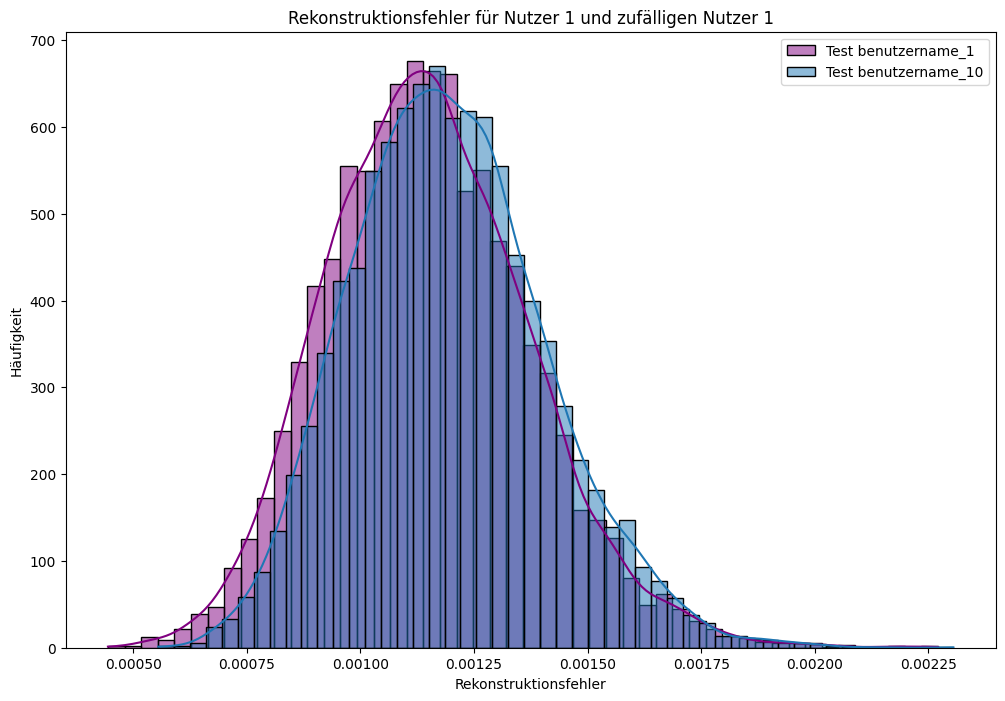

1/1 [==============================] - 0s 20ms/step


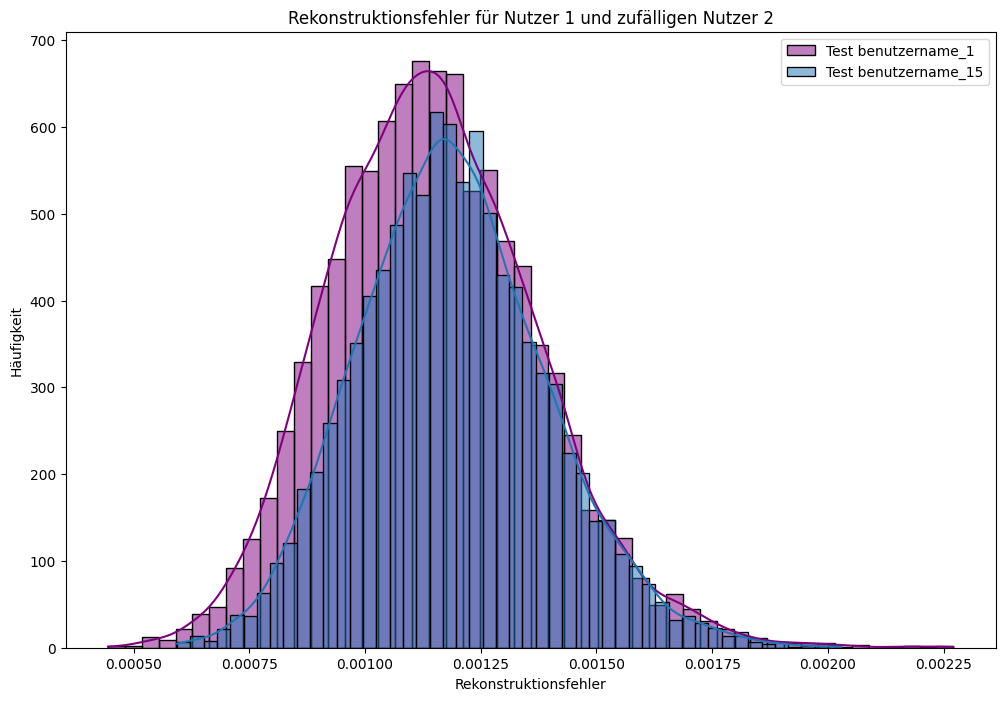

1/1 [==============================] - 0s 14ms/step


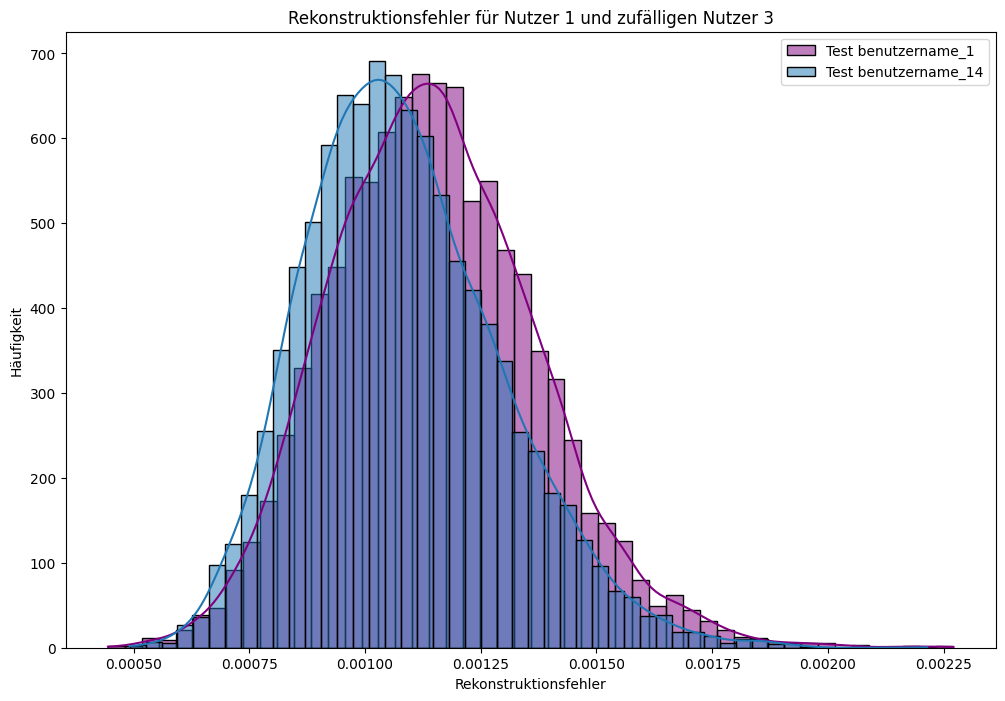

1/1 [==============================] - 0s 14ms/step


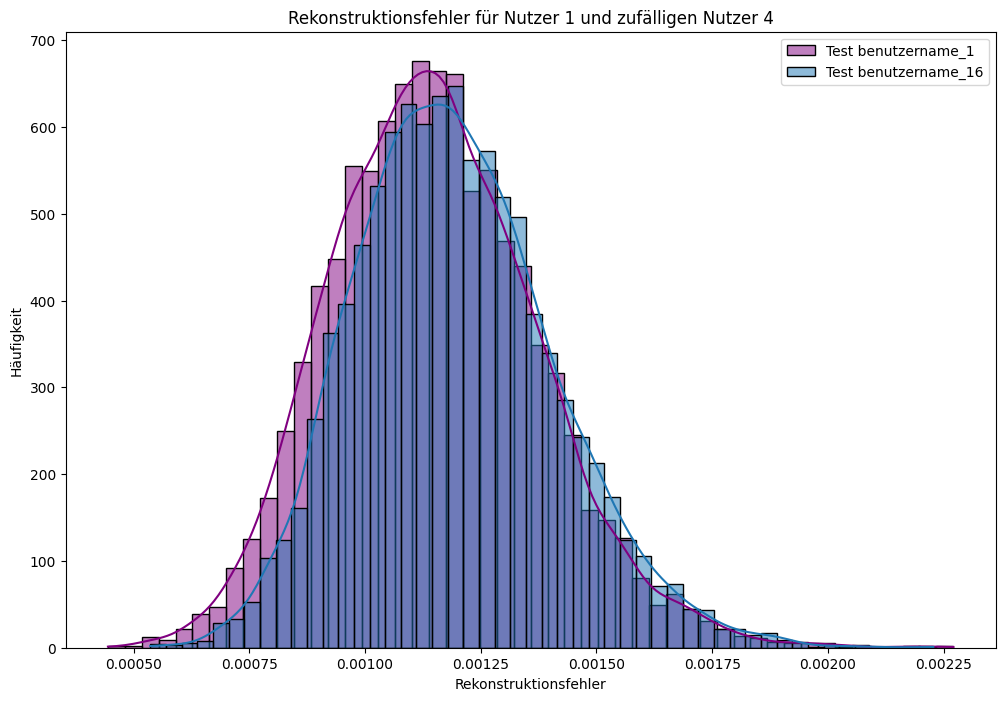

1/1 [==============================] - 0s 15ms/step


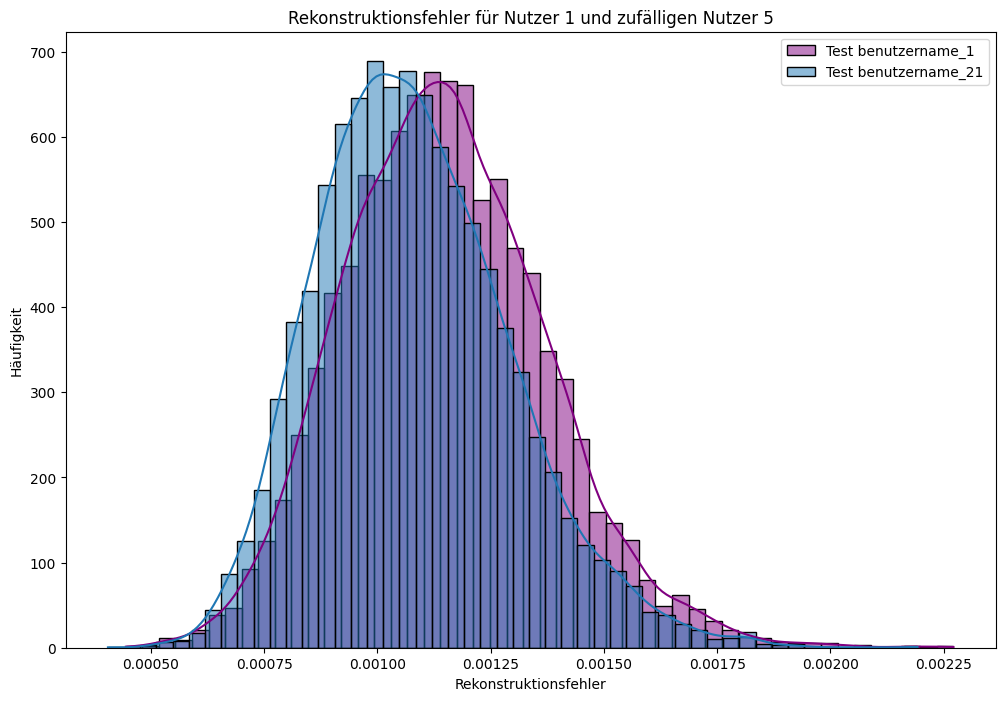

1/1 [==============================] - 0s 16ms/step

Bewertung der Modellleistung:
Durchschnittlicher Rekonstruktionsfehler (Nutzer 1): 0.001148952199832657
Durchschnittlicher Rekonstruktionsfehler (zufällige Nutzer): 0.0011845416812838769

Adaptive Erklärung der Ergebnisse:
Das Modell erkennt Nutzer 1 einigermaßen gut, aber es gibt Raum für Verbesserungen.


In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Berechnung der Rekonstruktionsfehler
def calculate_reconstruction_error(model, generator):
    reconstruction_errors = []
    for batch in generator:
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=(1, 2, 3))
        reconstruction_errors.extend(reconstruction_error)
    return np.array(reconstruction_errors)

# Berechnung der Rekonstruktionsfehler für eine begrenzte Anzahl von Testdaten
def calculate_reconstruction_error_limited(model, generator, limit=10000):
    reconstruction_errors = []
    count = 0
    for batch in generator:
        if count >= limit:
            break
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=(1, 2, 3))
        reconstruction_errors.extend(reconstruction_error)
        count += len(X)
    return np.array(reconstruction_errors[:limit])

# Rekonstruktionsfehler für Nutzer 1
user_1_id = user_ids[0]  # Assuming user 1 is the first user in the list
_, _, test_generator_user_1 = user_generators[user_1_id]
reconstruction_error_user_1 = calculate_reconstruction_error_limited(autoencoder, test_generator_user_1, limit=10000)

# Erstellen von 5 Diagrammen mit Nutzer 1 und einem zufälligen anderen Nutzer
for i in range(5):
    random_user_id = random.choice([uid for uid in user_ids if uid != user_1_id])
    _, _, test_generator_random_user = user_generators[random_user_id]
    reconstruction_error_random_user = calculate_reconstruction_error_limited(autoencoder, test_generator_random_user, limit=10000)
    
    plt.figure(figsize=(12, 8))
    sns.histplot(reconstruction_error_user_1, bins=50, kde=True, color='purple', label=f'Test {user_1_id}')
    sns.histplot(reconstruction_error_random_user, bins=50, kde=True, label=f'Test {random_user_id}')
    
    plt.title(f'Rekonstruktionsfehler für Nutzer 1 und zufälligen Nutzer {i+1}')
    plt.xlabel('Rekonstruktionsfehler')
    plt.ylabel('Häufigkeit')
    plt.legend()
    plt.show()

# Bewertung der Modellleistung
mean_user_1_error = np.mean(reconstruction_error_user_1)
mean_random_user_errors = []

for i in range(5):
    random_user_id = random.choice([uid for uid in user_ids if uid != user_1_id])
    _, _, test_generator_random_user = user_generators[random_user_id]
    reconstruction_error_random_user = calculate_reconstruction_error_limited(autoencoder, test_generator_random_user, limit=10000)
    mean_random_user_errors.append(np.mean(reconstruction_error_random_user))

mean_random_user_error = np.mean(mean_random_user_errors)

print("\nBewertung der Modellleistung:")
print(f"Durchschnittlicher Rekonstruktionsfehler (Nutzer 1): {mean_user_1_error}")
print(f"Durchschnittlicher Rekonstruktionsfehler (zufällige Nutzer): {mean_random_user_error}")

# Adaptive Erklärung der Ergebnisse
print("\nAdaptive Erklärung der Ergebnisse:")
if mean_user_1_error < min(mean_random_user_errors):
    print("Das Modell erkennt Nutzer 1 gut und unterscheidet ihn von anderen Nutzern.")
elif mean_user_1_error < np.mean(mean_random_user_errors):
    print("Das Modell erkennt Nutzer 1 einigermaßen gut, aber es gibt Raum für Verbesserungen.")
else:
    print("Das Modell hat Schwierigkeiten, Nutzer 1 von anderen Nutzern zu unterscheiden. Eine weitere Optimierung ist erforderlich.")

# Test mit 10.000 zufälligen Samples pro Nutzer
random_samples = []
random_labels = []

for _ in range(10000 * len(user_ids)):
    random_user_id = random.choice(user_ids)
    _, _, test_generator_random_user = user_generators[random_user_id]
    random_sample = next(iter(test_generator_random_user))[0][0]  # Nimm das erste Sample aus dem Generator
    random_samples.append(random_sample)
    random_labels.append(1 if random_user_id == user_1_id else 0)

random_samples = np.array(random_samples)
reconstruction_errors_random_samples = np.mean(np.square(random_samples - autoencoder.predict(random_samples)), axis=(1, 2, 3))

# Debugging-Ausgaben
print(f"Anzahl der zufälligen Samples: {len(random_samples)}")
print(f"Rekonstruktionsfehler für zufällige Samples: {reconstruction_errors_random_samples}")

# Grafische Darstellung der Rekonstruktionsfehler für zufällige Samples
plt.figure(figsize=(12, 8))
sns.histplot(reconstruction_errors_random_samples[np.array(random_labels) == 1], bins=50, kde=True, color='purple', label='Nutzer 1')
sns.histplot(reconstruction_errors_random_samples[np.array(random_labels) == 0], bins=50, kde=True, color='blue', label='Andere Nutzer')

plt.title('Rekonstruktionsfehler für zufällige Samples')
plt.xlabel('Rekonstruktionsfehler')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()

# Bewertung der Modellleistung für zufällige Samples
mean_error_user_1_samples = np.mean(reconstruction_errors_random_samples[np.array(random_labels) == 1])
mean_error_other_samples = np.mean(reconstruction_errors_random_samples[np.array(random_labels) == 0])

print("\nBewertung der Modellleistung für zufällige Samples:")
print(f"Durchschnittlicher Rekonstruktionsfehler (Nutzer 1 Samples): {mean_error_user_1_samples}")
print(f"Durchschnittlicher Rekonstruktionsfehler (Andere Nutzer Samples): {mean_error_other_samples}")

# Adaptive Erklärung der Ergebnisse für zufällige Samples
print("\nAdaptive Erklärung der Ergebnisse für zufällige Samples:")
if mean_error_user_1_samples < mean_error_other_samples:
    print("Das Modell erkennt zufällige Samples von Nutzer 1 gut und unterscheidet sie von anderen Nutzern.")
else:
    print("Das Modell hat Schwierigkeiten, zufällige Samples von Nutzer 1 von anderen Nutzern zu unterscheiden. Eine weitere Optimierung ist erforderlich.")

# Entscheidung, ob ein Sample als Nutzer 1 erkannt wird
threshold = (mean_error_user_1_samples + mean_error_other_samples) / 2
predictions = reconstruction_errors_random_samples < threshold

# Bewertung der Vorhersagen
true_positives = np.sum((predictions == 1) & (np.array(random_labels) == 1))
true_negatives = np.sum((predictions == 0) & (np.array(random_labels) == 0))
false_positives = np.sum((predictions == 1) & (np.array(random_labels) == 0))
false_negatives = np.sum((predictions == 0) & (np.array(random_labels) == 1))

print("\nVorhersageergebnisse:")
print(f"True Positives: {true_positives}")
print(f"True Negatives: {true_negatives}")
print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")

accuracy = (true_positives + true_negatives) / len(predictions)
print(f"Genauigkeit: {accuracy}")

# Adaptive Erklärung der Vorhersageergebnisse
print("\nAdaptive Erklärung der Vorhersageergebnisse:")
if accuracy > 0.8:
    print("Das Modell kann Nutzer 1 gut erkennen.")
elif accuracy > 0.6:
    print("Das Modell kann Nutzer 1 einigermaßen gut erkennen, aber es gibt Raum für Verbesserungen.")
else:
    print("Das Modell hat Schwierigkeiten, Nutzer 1 zu erkennen. Eine weitere Optimierung ist erforderlich.")